In [8]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ds = xr.open_dataset("../../NC/compare_diff.nc")


In [9]:
def calc_kurtosis_over_time(da):
    """
    da: xarray.DataArray with dims (time, lat, lon)
    return: pandas.Series indexed by time
    """
    kurt_list = []

    for t in da.time:
        values = da.sel(time=t).values
        values = values[~np.isnan(values)]

        mu = values.mean()
        sigma = values.std()

        kurt = np.mean(((values - mu) / sigma) ** 4) - 3
        kurt_list.append(kurt)

    return pd.Series(kurt_list, index=da.time.values)


In [10]:
kurt_basin  = calc_kurtosis_over_time(ds["basin_agri_diff"])
kurt_region = calc_kurtosis_over_time(ds["region_agri_diff"])


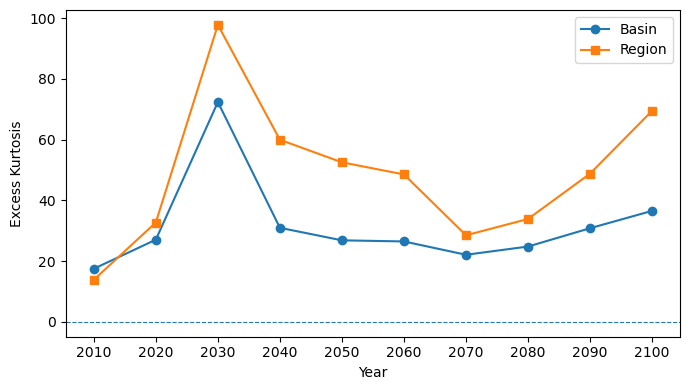

In [11]:
plt.figure(figsize=(7, 4))

plt.plot(kurt_basin.index, kurt_basin.values,
         marker="o", label="Basin")

plt.plot(kurt_region.index, kurt_region.values,
         marker="s", label="Region")

plt.axhline(0, linestyle="--", linewidth=0.8)

plt.xlabel("Year")
plt.ylabel("Excess Kurtosis")
plt.legend()
plt.tight_layout()
plt.savefig("../../plot/interannual_diff_kurtosis.png")
plt.show()
